In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from matplotlib_venn import venn2, venn3, venn3_unweighted
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

# Load in processed anndata

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.37 GB, difference +2.37 GB
CPU times: user 272 ms, sys: 1.63 s, total: 1.91 s
Wall time: 4.58 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

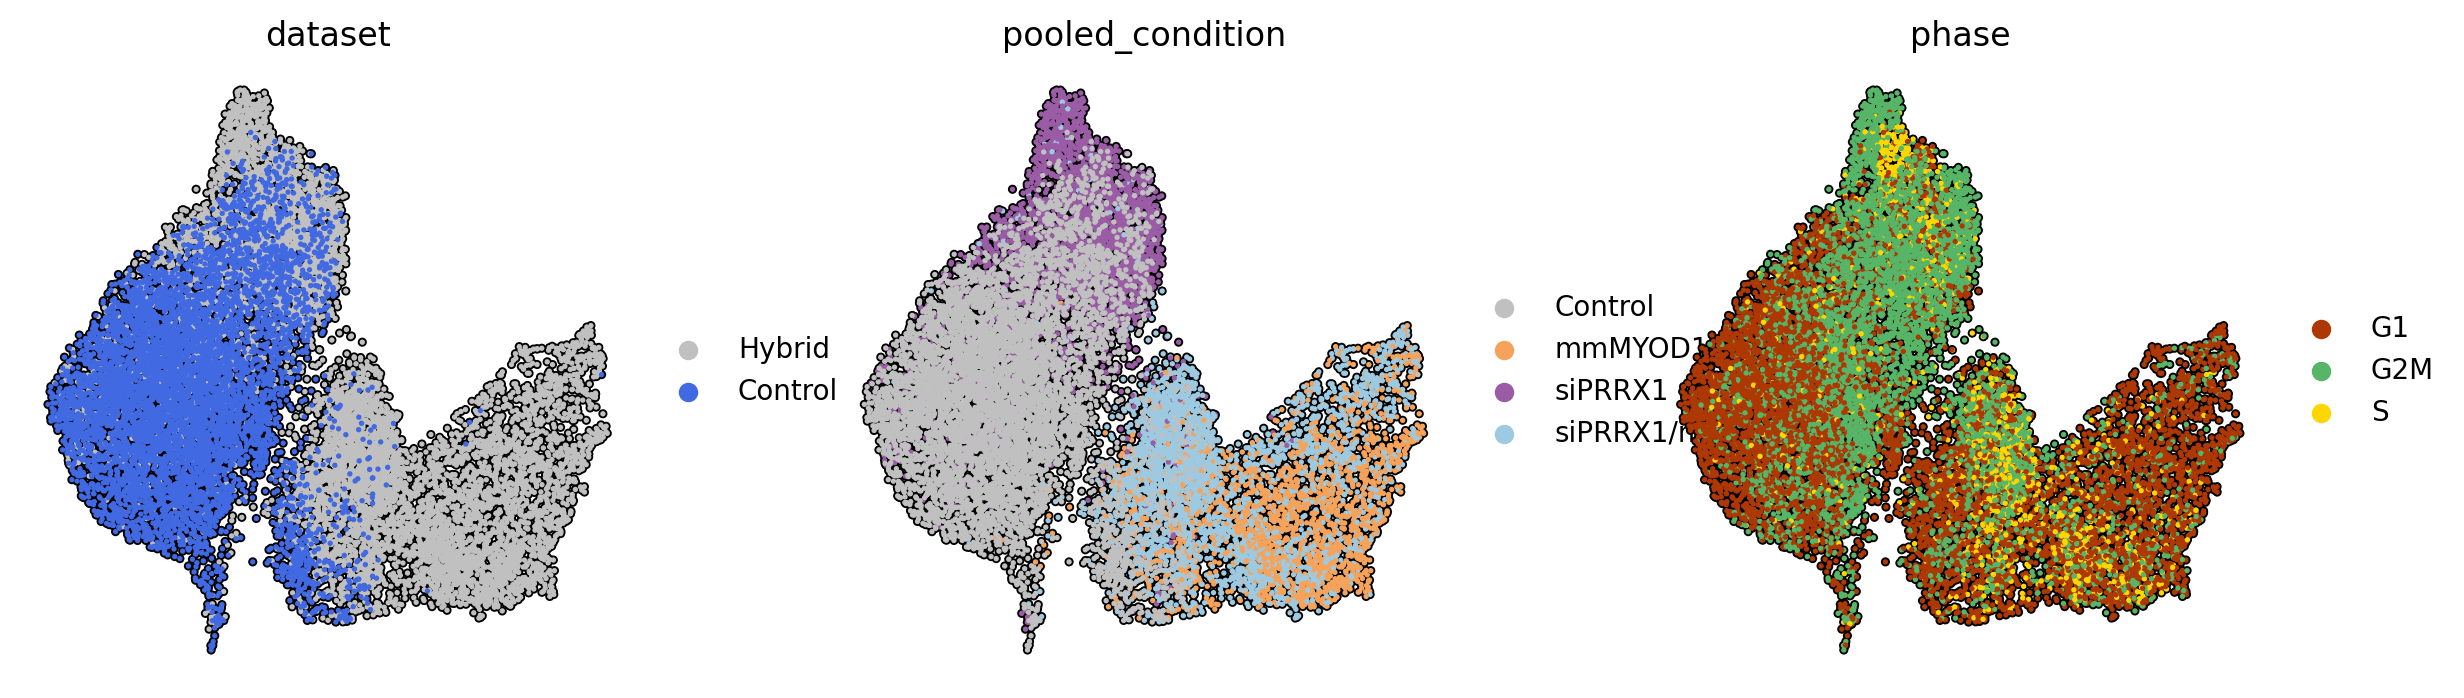

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'phase'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Load in gene sets

In [4]:
def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

mpath = "/nfs/turbo/umms-indikar/shared/projects/RECODE/marker_genes/PanglaoDB_Augmented_2021.txt"
pang = load_pathway(mpath)

cell_types = [
    'Fibroblasts',
    'Myocytes',
    'Myoblasts',
    'Myofibroblasts',
    'Pluripotent Stem Cells'
]

subset = pang[cell_types]

print("Marker genes per cell type:")
for ct in cell_types:
    print(f"{ct}: {subset[ct].sum()}")

panglao_markers = subset[subset.any(axis=1)]

print(f"\nTotal unique genes across selected types: {panglao_markers.shape[0]}")
panglao_markers.head()

fib_genes = panglao_markers['Fibroblasts'] == True
fib_genes =  panglao_markers[fib_genes].index
fib_genes = [g for g in fib_genes if g in adata.var_names]
print(len(fib_genes))

Marker genes per cell type:
Fibroblasts: 232
Myocytes: 163
Myoblasts: 126
Myofibroblasts: 100
Pluripotent Stem Cells: 112

Total unique genes across selected types: 563
220


In [41]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()


,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [43]:
[col for col in geneset if 'beta' in col.lower()]

['CD4-positive, Alpha-Beta T Cell Activation (GO:0035710)',
 'Alpha-Beta T Cell Activation (GO:0046631)',
 'Alpha-Beta T Cell Differentiation (GO:0046632)',
 'Amino-Acid Betaine Metabolic Process (GO:0006577)',
 'Amino-Acid Betaine Transport (GO:0015838)',
 'Amyloid-Beta Formation (GO:0034205)',
 'Amyloid-Beta Metabolic Process (GO:0050435)',
 'Cellular Response to Amyloid-Beta (GO:1904646)',
 'Cellular Response to Interferon-Beta (GO:0035458)',
 'Cellular Response to Transforming Growth Factor Beta Stimulus (GO:0071560)',
 'Fatty Acid Beta-Oxidation (GO:0006635)',
 'Fatty Acid Beta-Oxidation Using acyl-CoA Dehydrogenase (GO:0033539)',
 'Fatty Acid Beta-Oxidation Using acyl-CoA Oxidase (GO:0033540)',
 'Negative Regulation of CD4-positive, Alpha-Beta T Cell Activation (GO:2000515)',
 'Negative Regulation of CD4-positive, Alpha-Beta T Cell Proliferation (GO:2000562)',
 'Negative Regulation of CD8-positive, Alpha-Beta T Cell Activation (GO:2001186)',
 'Negative Regulation of Alpha-Beta T 

In [44]:
### TGFB signaling
cols = [
    'Negative Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030512)',
    'Positive Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030511)',
    'Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0017015)',
    'Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0007179)',
    'Transforming Growth Factor Beta Receptor Superfamily Signaling Pathway (GO:0141091)',
    'Response to Transforming Growth Factor Beta (GO:0071559)',
]

tgfb = geneset[cols]
tgfb.head()

,Negative Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030512),Positive Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030511),Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0017015),Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0007179),Transforming Growth Factor Beta Receptor Superfamily Signaling Pathway (GO:0141091),Response to Transforming Growth Factor Beta (GO:0071559)
0,GDF15,CREBBP,ADISSP,TGFB1,GDF11,SMAD3
1,SMURF2,CDKN1C,GDF15,TGFB3,TGFB1,TGFB1
2,SMURF1,CITED1,CIDEA,JUN,TGFB3,WWOX
3,TET1,SMAD4,HIPK2,TGFB2,TGFB2,MEF2C
4,CIDEA,CITED2,SOX11,GDF15,GDF15,SMAD4


# DGE

mmMYOD1, siPRRX1, siPRRX1/mmMYOD1, Controls

In [5]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    """ Filters DGE results for significant differentially expressed genes. 
    
    Params
    ------
        df (pd.DataFrame): Dataframe containing DGE results.
        alpha (float): Adjusted p-value threshold for statistical significance. Genes below this threshold are considered significant.
        logfc_thresh (float): Minimum absolute logfoldchange required for a gene to be considered significantly DE. 
        pct_nz_thresh (float): Minimum proportion of cells in the group of interest expressing the gene. Genes expressed in fewer cells than this threshold will be excluded.
    
    """
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]

    
    if pct_nz_thresh != 0.0:
        if 'pct_nz_reference' in tmp.columns:
            tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
        else:
            tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

In [6]:
# # all groups vs each other
# sc.tl.rank_genes_groups(
#     adata, 
#     groupby="pooled_condition",
#     method='wilcoxon',
#     corr_method='benjamini-hochberg',
#     use_raw=False,
#     layer='log_norm',
#     pts=True,
#     key_added='each_vs_rest',
# )

# hyb groups vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_vs_control',
)

ranking genes
    finished (0:01:05)


In [11]:
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='condition_vs_control',
)


sig = get_significant_DEGs(deg, logfc_thresh=0.2)

# filter for upregulated genes that are expressed in a certain proportion of cells
pct_thresh = 0.25

sig = sig[
    (sig['logfoldchanges'] < 0) | # retain all downregulated genes
    ((sig['logfoldchanges'] > 0) & (sig['pct_nz_group'] >= pct_thresh))
]

print(f'N genes: {sig['names'].nunique()}')


sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.2)...
N unique significant DEGs: 11797

N genes: 7377


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513
1,mmMYOD1,MT-ND4,69.559166,2.778089,0.0,0.0,0.999526,2.778089
2,mmMYOD1,LINC-PINT,59.171329,2.708041,0.0,0.0,0.970128,2.708041
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306


In [12]:
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='names')

pdf = pd.merge(sig, gdf, how='left', on='names')

pdf.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513,protein_coding,False,False
1,mmMYOD1,MT-ND4,69.559166,2.778089,0.0,0.0,0.999526,2.778089,protein_coding,True,False
2,mmMYOD1,LINC-PINT,59.171329,2.708041,0.0,0.0,0.970128,2.708041,lncRNA,False,False
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840,protein_coding,False,False
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306,protein_coding,False,False


mmMYOD1 N genes: 572
siPRRX1 N genes: 525
siPRRX1/mmMYOD1 N genes: 551


[Text(0, 0.5, '0.0'),
 Text(0, 0.6000000000000001, '0.6'),
 Text(0, 0.7000000000000001, '0.7'),
 Text(0, 0.8, '0.8'),
 Text(0, 0.9, '0.9'),
 Text(0, 1.0, '1.0')]

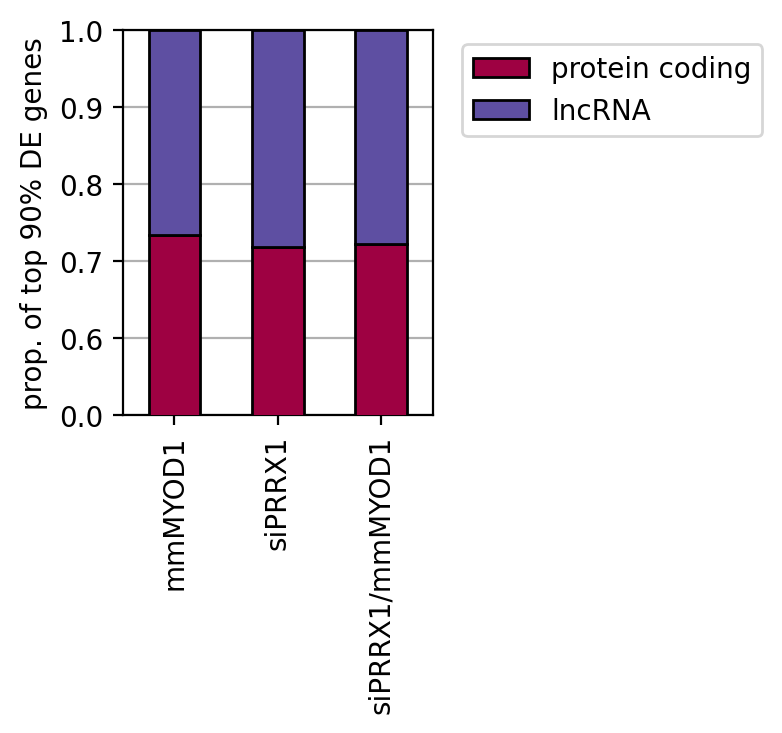

In [32]:
keep = [
    'protein_coding',
    'lncRNA',
]

pdf = pdf[pdf['gene_type'].isin(keep)]

p = 0.9

proportions = {}

for group, sub in pdf.groupby('group'):
    # threshold for top p quantile
    sub = sub.copy()
    thresh = sub['abs_lfc'].quantile(p)

    # keep those above threshold
    top_sub = sub[sub['abs_lfc'] >= thresh]
    print(f"{group} N genes: {top_sub['names'].nunique()}")
    # proportions by gene_type
    cnts = top_sub['gene_type'].value_counts(normalize=True)
    cnts.index = cnts.index.str.replace("_", " ")
    proportions[group] = cnts

# assemble into dataframe
result = pd.DataFrame(proportions).fillna(0)

# order categories so protein coding is first
order = ['protein coding', 'lncRNA']
result = result.reindex(order)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2, 2.5

ax = result.T.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral',
)

plt.grid(axis='y', zorder=0)
sns.move_legend(
    ax,
    loc='upper left',
    title='',
    bbox_to_anchor=(1.05, 1)
)

plt.ylabel(f'prop. of top {int(p*100)}% DE genes')
plt.xticks(rotation=90)
plt.ylim([0.5, 1])

ax = plt.gca()
yticks = ax.get_yticks()
yticklabels = [f"{round(t, 3)}" for t in yticks]
yticklabels[0] = 0.0    # set lowest label manually
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

In [33]:
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='names')

pdf = pd.merge(sig, gdf, how='left', on='names')

print("Removing non protein-coding, unnamed, and mitochondrial genes...\n")

pdf = pdf[pdf['gene_type'] == 'protein_coding'] # get only protein-coding genes
pdf = pdf[~pdf['names'].str.startswith(('ENSG', 'MT-'))] # remove unnamed and MT genes
# pdf = pdf[~pdf['ribo']] # remove ribosomal genes

print(f"N unique DE protein-coding genes: {pdf['names'].nunique()}\n")

for i in pdf['group'].unique():
    tmp = pdf[pdf['group'] == i]
    print(f"N upregulated genes for {i}: {tmp[tmp['logfoldchanges'] > 0]['names'].nunique()}")
    print(f"N downregulated genes for {i}: {tmp[tmp['logfoldchanges'] < 0]['names'].nunique()}\n")

pdf.head()

Removing non protein-coding, unnamed, and mitochondrial genes...

N unique DE protein-coding genes: 6889

N upregulated genes for mmMYOD1: 2753
N downregulated genes for mmMYOD1: 2598

N upregulated genes for siPRRX1: 3254
N downregulated genes for siPRRX1: 1632

N upregulated genes for siPRRX1/mmMYOD1: 2779
N downregulated genes for siPRRX1/mmMYOD1: 2355



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513,protein_coding,False,False
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840,protein_coding,False,False
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306,protein_coding,False,False
5,mmMYOD1,KCNQ5,54.305904,2.960109,0.0,0.0,0.952584,2.960109,protein_coding,False,False
6,mmMYOD1,IFIT3,52.313427,1.631886,0.0,0.0,0.984353,1.631886,protein_coding,False,False


## Opposites

In [34]:
mmMYOD1_df = pdf[pdf['group'] == "mmMYOD1"][['names', 'logfoldchanges']]
siPRRX1_df = pdf[pdf['group'] == "siPRRX1"][['names', 'logfoldchanges']]

mmMYOD1_df = mmMYOD1_df.rename(columns={'logfoldchanges': 'logfold_mmMYOD1'})
siPRRX1_df = siPRRX1_df.rename(columns={'logfoldchanges': 'logfold_siPRRX1'})

merged = mmMYOD1_df.merge(siPRRX1_df, on='names', how='inner')

opposite_genes = merged[
    (merged['logfold_mmMYOD1'] > 0) & (merged['logfold_siPRRX1'] < 0) |
    (merged['logfold_mmMYOD1'] < 0) & (merged['logfold_siPRRX1'] > 0)
].copy()

opposite_genes['diff_magnitude'] = (
    abs(opposite_genes['logfold_mmMYOD1']) + abs(opposite_genes['logfold_siPRRX1'])
)

opposite_genes_sorted = opposite_genes.sort_values(by='diff_magnitude', ascending=False)
print(opposite_genes_sorted.shape)
opposite_genes_sorted.head(20)

(852, 4)


,names,logfold_mmMYOD1,logfold_siPRRX1,diff_magnitude
80,ATF3,3.716762,-2.081517,5.798279
6,IFIT2,2.811286,-1.911914,4.723200
18,OASL,3.443441,-0.845054,4.288495
15,ISG20,2.806341,-1.106180,3.912521
464,IL6,1.764895,-2.077540,3.842436
1852,EGR1,1.045200,-2.785572,3.830772
265,GBP4,2.213243,-1.548525,3.761769
125,IL32,2.749399,-0.970666,3.720065
264,TNFSF10,2.677775,-1.002306,3.680081
20,PMAIP1,3.132335,-0.456729,3.589063


In [37]:
tmp = get_significant_DEGs(deg, logfc_thresh=0.0)
tmp = tmp[~tmp['names'].str.startswith(('MT', 'ENSG'))]

mmMYOD1_df = tmp[tmp['group'] == "mmMYOD1"][['names', 'logfoldchanges']]
siPRRX1_df = tmp[tmp['group'] == "siPRRX1"][['names', 'logfoldchanges']]
combo_df = tmp[tmp['group'] == "siPRRX1/mmMYOD1"][['names', 'logfoldchanges']]

# Rename columns
mmMYOD1_df = mmMYOD1_df.rename(columns={'logfoldchanges': 'logfold_mmMYOD1'})
siPRRX1_df = siPRRX1_df.rename(columns={'logfoldchanges': 'logfold_siPRRX1'})
combo_df = combo_df.rename(columns={'logfoldchanges': 'logfold_combo'})

# Merge all three
merged = mmMYOD1_df.merge(siPRRX1_df, on='names', how='inner').merge(combo_df, on='names', how='inner')

# Define regulation signs
merged['sign_mmMYOD1'] = merged['logfold_mmMYOD1'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
merged['sign_siPRRX1'] = merged['logfold_siPRRX1'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
merged['sign_combo'] = merged['logfold_combo'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))


opposite_genes = merged[merged['sign_mmMYOD1'] != merged['sign_siPRRX1']].copy()
# Keep genes where combo is closer to siPRRX1
opposite_genes['closer_to_siPRRX1'] = (
    abs(opposite_genes['logfold_combo'] - opposite_genes['logfold_siPRRX1']) <
    abs(opposite_genes['logfold_combo'] - opposite_genes['logfold_mmMYOD1'])
)
target_genes = opposite_genes[opposite_genes['closer_to_siPRRX1']].copy()

target_genes['diff_magnitude'] = (
    abs(target_genes['logfold_mmMYOD1']) + abs(target_genes['logfold_siPRRX1'])
)

target_genes['diff_combo'] = (
    abs(target_genes['logfold_mmMYOD1']) + abs(target_genes['logfold_combo'])
)

target_genes_sorted = target_genes.sort_values(by=['diff_magnitude', 'diff_combo'], ascending=[False, True])

target_genes_sorted.head(20)

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.0)...
N unique significant DEGs: 12061



,names,logfold_mmMYOD1,logfold_siPRRX1,logfold_combo,sign_mmMYOD1,sign_siPRRX1,sign_combo,closer_to_siPRRX1,diff_magnitude,diff_combo
5698,KDELR3,-1.928092,0.666524,-0.540085,-1,1,-1,True,2.594615,2.468177
6019,CALR,-1.653755,0.871217,-0.277473,-1,1,-1,True,2.524972,1.931229
5161,KIF20A,-1.529719,0.993225,-0.164396,-1,1,-1,True,2.522943,1.694114
5639,GGH,-1.712908,0.571395,-0.452794,-1,1,-1,True,2.284303,2.165702
6106,CD99,-2.063201,0.152379,-0.819488,-1,1,-1,True,2.215581,2.882689
6073,APLP2,-2.055195,0.046901,-0.928512,-1,1,-1,True,2.102096,2.983707
5973,PDIA4,-1.779235,0.306872,-0.492862,-1,1,-1,True,2.086108,2.272097
5174,MATN2,-1.671800,0.382360,-0.448769,-1,1,-1,True,2.054160,2.120569
4976,MMAB,-1.460447,0.574221,-0.289939,-1,1,-1,True,2.034667,1.750386
5597,FADS1,-1.523300,0.494933,-0.367446,-1,1,-1,True,2.018232,1.890745


In [39]:
target_genes_sorted['names'].unique()

array(['KDELR3', 'CALR', 'KIF20A', 'GGH', 'CD99', 'APLP2', 'PDIA4',
       'MATN2', 'MMAB', 'FADS1', 'PDIA6', 'PRC1', 'FKBP7', 'TBC1D8B',
       'HSPB6', 'VIT', 'UGCG', 'SMAD1', 'NUCB2', 'TUBA1B', 'ZDHHC12-DT',
       'CD248', 'NUF2', 'SERTAD2', 'IKBIP', 'SFRP1', 'GAS5', 'DHCR24',
       'LGALS1', 'PRDX2', 'TK1', 'TECR', 'PTTG1', 'PRSS12', 'EBP',
       'TRAPPC1', 'SSR2', 'KIF4A', 'ANXA2', 'ETS1', 'RPN2', 'SMC2',
       'PCLAF', 'HERPUD1', 'NUSAP1', 'VIM', 'GTSE1', 'PVR', 'MYDGF',
       'FXYD5', 'EHD3', 'LZTS2', 'HINT1', 'CENPW', 'PNKD', 'QPRT',
       'ANP32E', 'CSGALNACT2', 'TRIP13', 'SNHG9', 'ALDH1A1', 'DCTN3',
       'RPA3', 'ZDHHC12', 'CAPNS1', 'SOD1', 'LMNA', 'CFL1', 'TROAP',
       'DNASE1L1', 'DDOST', 'FKBP11', 'PHPT1', 'NCAPG', 'ASAH1', 'TUBE1',
       'PHF19', 'BCAP31', 'SEC13', 'PALM2AKAP2', 'TSPAN4', 'DNAJB11',
       'PNRC1', 'SLC7A11', 'NEXN', 'CHMP1B', 'ERGIC3', 'ARL2', 'KIF2C',
       'ADM', 'FKBP2', 'SH3BGRL3', 'SPC24', 'TMEM97', 'AP2S1', 'S100A10',
       'LY6E', 'IT

In [40]:
genes = ['SMAD1', 'ETS1', 'PCLAF', 'VIM', 'MYDGF', 'SERPINB6', 'TMPO', 'BEX3', 'ATF1', 'TNFRSF1A', 'COL11A1', 'RBPJ', 'MDK', 'BAX', 'MYL12B', 'FLT1']
target_genes_sorted[target_genes_sorted['names'].isin(genes)]

,names,logfold_mmMYOD1,logfold_siPRRX1,logfold_combo,sign_mmMYOD1,sign_siPRRX1,sign_combo,closer_to_siPRRX1,diff_magnitude,diff_combo
4034,SMAD1,0.554573,-1.233646,-0.651476,1,-1,-1,True,1.788220,1.206049
386,ETS1,1.151108,-0.313665,0.401156,1,-1,1,True,1.464773,1.552264
5605,PCLAF,-1.149538,0.307299,-0.103590,-1,1,-1,True,1.456837,1.253128
6055,VIM,-1.337426,0.107734,-0.605627,-1,1,-1,True,1.445160,1.943053
5924,MYDGF,-1.120232,0.314850,-0.276439,-1,1,-1,True,1.435082,1.396670
5536,TMPO,-0.922437,0.113040,-0.315154,-1,1,-1,True,1.035476,1.237591
5303,SERPINB6,-0.670926,0.343465,-0.133971,-1,1,-1,True,1.014391,0.804897
5807,BEX3,-0.878546,0.046000,-0.327799,-1,1,-1,True,0.924546,1.206345
2890,ATF1,0.598862,-0.272055,-0.140190,1,-1,-1,True,0.870917,0.739053
2356,TNFRSF1A,0.491796,-0.315259,-0.087387,1,-1,-1,True,0.807055,0.579183


## PRRX1

In [47]:
prrx = pdf[pdf['group'] == 'siPRRX1'].copy()

prrx.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
5721,siPRRX1,GAPDH,74.524040,0.985153,0.0,0.0,1.000000,0.985153,protein_coding,False,False
5723,siPRRX1,GMNN,66.456146,2.341715,0.0,0.0,0.976385,2.341715,protein_coding,False,False
5724,siPRRX1,NPM1,65.107552,1.073052,0.0,0.0,0.999708,1.073052,protein_coding,False,False
5726,siPRRX1,PSMA7,57.771744,0.903040,0.0,0.0,0.999708,0.903040,protein_coding,False,False
5727,siPRRX1,NCL,55.786682,0.987533,0.0,0.0,1.000000,0.987533,protein_coding,False,False


In [55]:
# pd.set_option('display.max_colwidth', None)
n_genes = 300

up = prrx[prrx['logfoldchanges'] > 0]
up_genes = up.sort_values(by='logfoldchanges', ascending=False)['names'].head(n_genes)

down = prrx[prrx['logfoldchanges'] < 0]
down_genes = down.sort_values(by='logfoldchanges', ascending=True)['names'].head(n_genes)

database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

enr = gget.enrichr(
    up_genes,
    database,
    save=False,
)

display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(15))
print("=" * 100 + "\n")

17:39:56 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val
0,Negative Regulation of DNA Metabolic Process (GO:0051053),"[H1-5, H1-4, GMNN, CDC6, H1-1, H1-3, H1-2]",0.003034
1,Regulation of Small GTPase Mediated Signal Transduction (GO:0051056),"[DOCK10, ARHGAP22, STARD13, DNMBP, OPHN1, ARHGEF28, ITSN1, DENND4C, ARHGAP18, ARHGEF18, SLIT2, DOCK2]",0.003034
2,Regulation of Cell-Matrix Adhesion (GO:0001952),"[SFRP1, PGAP1, PLAU, CDH13, PIK3CB, NF2, CLASP1, PTK2]",0.003034
3,Regulation of DNA Recombination (GO:0000018),"[H1-5, H1-4, SETD2, H1-1, H1-3, H1-2]",0.010979
4,Regulation of Cell Migration (GO:0030334),"[WNT5B, SEMA3A, MEAK7, MITF, PPP2R3A, PTK2, DOCK10, FRMD5, SFRP1, CASP8, NAV3, PLAU, MGAT5, PDGFC, HAS2, CDH13, PHACTR1, SLIT2, NF2, SCAI]",0.013101
5,Proteasome-Mediated Ubiquitin-Dependent Protein Catabolic Process (GO:0043161),"[SMURF2, SMURF1, FAF1, FBXL17, UBR3, KLHL22, UBE4B, FBXL14, KLHL20, PCNP, PSMD2, UBR5, MDM2, ERCC8, FBXL2, ANAPC1]",0.016072
6,Chromosome Organization (GO:0051276),"[H1-5, H1-4, GMNN, H1-1, H1-3, H1-2]",0.016072
7,Chromosome Condensation (GO:0030261),"[H1-5, H1-4, H1-1, H1-3, H1-2]",0.018372
8,Regulation of Rho Protein Signal Transduction (GO:0035023),"[DOCK10, STARD13, PRAG1, OPHN1, ARHGEF28, ARHGEF18, SCAI]",0.025912
9,Positive Regulation of Cell Migration (GO:0030335),"[DOCK5, SMURF2, WNT5B, SEMA3A, PIK3CB, PTK2, ZNF609, CASP8, PLAU, MGAT5, PDGFC, HAS2, CDH13, PLCG1, CLASP1]",0.036921


In [56]:
enr = gget.enrichr(
    down_genes,
    database,
    save=False,
)

display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(15))
print("=" * 100 + "\n")

17:40:41 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val
0,Extracellular Matrix Organization (GO:0030198),"[APP, POSTN, COL15A1, COL16A1, LUM, MMP2, MMP3, FURIN, TGFBR1, COL1A1, GREM1, COL3A1, COL4A2, COL4A1, COL5A3, CTSK, COL7A1, CYP1B1, TGFBI]",7.841315e-08
1,Regulation of Angiogenesis (GO:0045765),"[XBP1, FOXC1, CXCL8, PTGIS, SERPINF1, WNT5A, THBS2, KLF4, HIF1A, DCN, WARS1, VEGFA, IL6, GPNMB, COL4A2, ADM2, CYP1B1, CTSH, CHI3L1]",5.053665e-07
2,Extracellular Structure Organization (GO:0043062),"[APP, POSTN, COL15A1, COL16A1, MMP2, MMP3, FURIN, TGFBR1, COL3A1, COL4A2, COL4A1, COL5A3, COL7A1, TGFBI]",8.515920e-07
3,Positive Regulation of Macromolecule Biosynthetic Process (GO:0010557),"[EGR1, APP, XBP1, CXCL8, WNT5A, IGF2, SOX11, IRS2, INHBA, KLF4, NGF, HIF1A, CLU, WARS1, TGFBR1, VEGFA, IL6, ACTC1, SLC6A9, ADM2, CCL2, CTSH, ATF4]",2.430629e-06
4,External Encapsulating Structure Organization (GO:0045229),"[APP, POSTN, COL15A1, COL16A1, MMP2, MMP3, FURIN, COL3A1, COL4A2, COL4A1, COL5A3, COL7A1, TGFBI]",5.030101e-06
5,Integrated Stress Response Signaling (GO:0140467),"[HERC5, CEBPB, BATF3, MAF, CEBPD, CEBPG, FOS, ATF4]",1.045124e-05
6,Positive Regulation of Apoptotic Process (GO:0043065),"[NANOS1, APP, XBP1, PTGIS, GADD45B, IGFBP3, WNT5A, HTRA1, CLU, TGFBR1, IFIT2, IL6, ADAMTSL4, CARM1, CCL2, CYP1B1, CTSH, NUPR1, ATF4]",8.656178e-05
7,Cellular Response to Growth Factor Stimulus (GO:0071363),"[NANOS1, XBP1, FOXC1, CXCL8, WNT5A, KLF4, TGFBR1, VEGFA, NR4A1, ZFP36, MT1G, CCL2, WNT2]",1.020078e-04
8,Positive Regulation of Angiogenesis (GO:0045766),"[SMAD1, XBP1, CXCL8, PTGIS, ADM2, WNT5A, CYP1B1, CTSH, CHI3L1, KLF4, HIF1A, VEGFA]",1.020078e-04
9,Regulation of miRNA Transcription (GO:1902893),"[APP, EGR1, IL6, NFIB, SRF, FOS, KLF4, HIF1A, VEGFA]",1.112630e-04


In [45]:
tgfb.head()

,Negative Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030512),Positive Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030511),Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0017015),Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0007179),Transforming Growth Factor Beta Receptor Superfamily Signaling Pathway (GO:0141091),Response to Transforming Growth Factor Beta (GO:0071559)
0,GDF15,CREBBP,ADISSP,TGFB1,GDF11,SMAD3
1,SMURF2,CDKN1C,GDF15,TGFB3,TGFB1,TGFB1
2,SMURF1,CITED1,CIDEA,JUN,TGFB3,WWOX
3,TET1,SMAD4,HIPK2,TGFB2,TGFB2,MEF2C
4,CIDEA,CITED2,SOX11,GDF15,GDF15,SMAD4


85
24
computing score 'neg_tgfb'
    finished (0:00:02)
computing score 'pos_tgfb'
    finished (0:00:01)


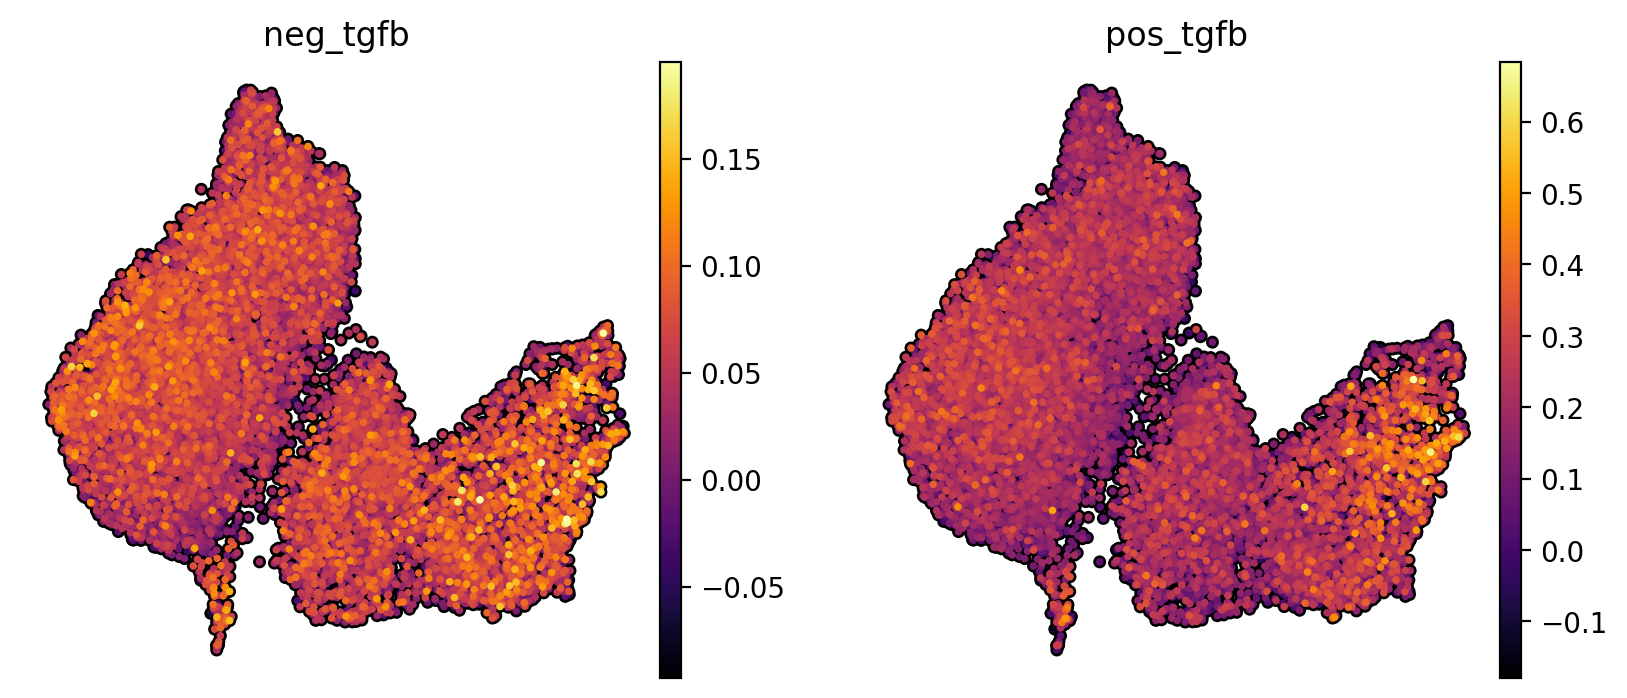

In [50]:
neg_tgfb = tgfb['Negative Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030512)'].dropna().unique()
print(len(neg_tgfb))

pos_tgfb = tgfb['Positive Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030511)'].dropna().unique()
print(len(pos_tgfb))

sc.tl.score_genes(
    adata,
    gene_list=neg_tgfb,
    score_name='neg_tgfb',
    ctrl_size=500,
    use_raw=False,
    layer='log_norm',
) 

sc.tl.score_genes(
    adata,
    gene_list=pos_tgfb,
    score_name='pos_tgfb',
    ctrl_size=500,
    use_raw=False,
    layer='log_norm',
) 

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['neg_tgfb', 'pos_tgfb'],
    size=30,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    color_map='inferno',
    frameon=False,
    alpha=1,
)

<Axes: xlabel='pooled_condition', ylabel='pos_tgfb'>

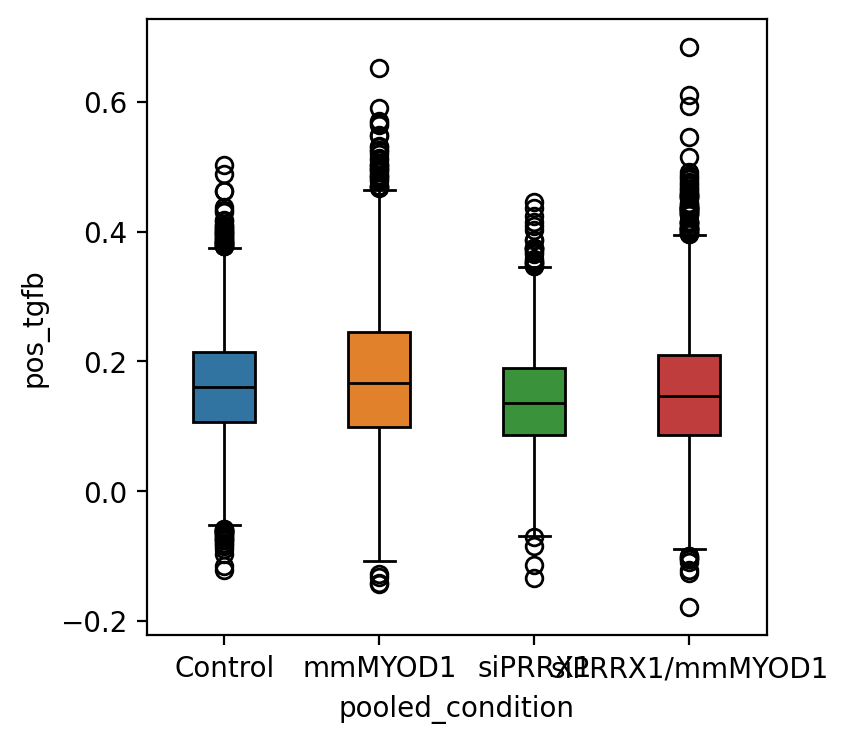

In [52]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.boxplot(
    data=adata.obs,
    x='pooled_condition',
    y='pos_tgfb',
    width=0.4,
    linecolor='k',
    hue='pooled_condition',
    legend=False,
)